**Table of contents**<a id='toc0_'></a>    
- [Photoswitching fingerprints of 1 fluorophore - global bleaching times](#toc1_)    
  - [CDF Fitting procedure](#toc1_1_)    
  - [Reading and fitting data](#toc1_2_)    
    - [Bleaching rate data](#toc1_2_1_)    
    - [ON to OFF data](#toc1_2_2_)    
    - [OFF to ON data](#toc1_2_3_)    
  - [Figure](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswitching fingerprints of 1 fluorophore - global bleaching times](#toc0_)

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from lmfit import Model, Parameters

import fluopy.blinking as bl
import fluopy.distributions as dist
import fluopy.emissions as em
import fluopy.figure as fi

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

for package in [bl, dist, em, fi]:
    print(f"{package.__name__} version: {package.__version__}")

reading_from = r"D:\python_output\Chapter_I\0_3_single_f_PFA"
saving_to = r"D:\python_output\Chapter_I\1_4_single_f_PFA_gl_bl_times"

fluopy.blinking version: 0.1.0
fluopy.distributions version: 0.1.0
fluopy.emissions version: 0.1.0
fluopy.figure version: 0.1.0


## <a id='toc1_1_'></a>[CDF Fitting procedure](#toc0_)

In [2]:
def fit_two_expon_mixture(data):
    x = np.linspace(0, 300, 300001)
    model = Model(dist.two_expon_mixture_cdf)
    params = Parameters()
    params.add("p", value=0.5, min=0, max=1)
    params.add("lambda1", value=1, min=0)
    params.add("lambda2", value=0.5, min=0)
    result = model.fit(data, params, x=x)
    parameters = [param.value for param in result.params.values()]

    return parameters

## <a id='toc1_2_'></a>[Reading and fitting data](#toc0_)

### <a id='toc1_2_1_'></a>[Bleaching rate data](#toc0_)

In [3]:
identifiers = ["1e1", "1e2", "1e3", "1e4"]
fingerprints_all_A = []
bleaching_times_all_A = []
parameters_all_fit_cdf_A = []
folder_path = reading_from + r"\bl_rate"
for i, id in enumerate(identifiers):
    fingerprints_all_A.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    bleaching_times_all_A.append([])
    for file in glob.glob(folder_path + "\\" + id + "/*"):
        if file.endswith(".parquet"):
            fingerprints_all_A[i] += pd.read_parquet(file).sum(axis=1)
        elif file.endswith(".npy"):
            bleaching_times_all_A[i] = np.load(file)
    fingerprint = fingerprints_all_A[i].cumsum() / fingerprints_all_A[i].sum()
    fingerprints_all_A[i] = fingerprint
    parameters_all_fit_cdf_A.append(fit_two_expon_mixture(fingerprint))

### <a id='toc1_2_2_'></a>[ON to OFF data](#toc0_)

In [5]:
identifiers = ["1", "01", "005", "001"]
fingerprints_all_B = []
bleaching_times_all_B = []
parameters_all_fit_cdf_B = []
folder_path = reading_from + r"\off_prob"
for i, id in enumerate(identifiers):
    fingerprints_all_B.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    bleaching_times_all_B.append([])
    for file in glob.glob(folder_path + "\\" + id + "/*"):
        if file.endswith(".parquet"):
            data = pd.read_parquet(file)
            fingerprints_all_B[i] += data.sum(axis=1)
        elif file.endswith(".npy"):
            bleaching_times_all_B[i] = np.load(file)
    fingerprint = fingerprints_all_B[i].cumsum() / fingerprints_all_B[i].sum()
    fingerprints_all_B[i] = fingerprint
    parameters_all_fit_cdf_B.append(fit_two_expon_mixture(fingerprint))

### <a id='toc1_2_3_'></a>[OFF to ON data](#toc0_)

In [6]:
identifiers = ["5e-2", "5e-1", "5e0", "5e1"]
fingerprints_all_C = []
bleaching_times_all_C = []
parameters_all_fit_cdf_C = []
folder_path = reading_from + r"\off_time"
for i, id in enumerate(identifiers):
    fingerprints_all_C.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    bleaching_times_all_C.append([])
    for file in glob.glob(folder_path + "\\" + id + "/*"):
        if file.endswith(".parquet"):
            data = pd.read_parquet(file)
            fingerprints_all_C[i] += data.sum(axis=1)
        elif file.endswith(".npy"):
            bleaching_times_all_C[i] = np.load(file)
    fingerprint = fingerprints_all_C[i].cumsum() / fingerprints_all_C[i].sum()
    fingerprints_all_C[i] = fingerprint
    parameters_all_fit_cdf_C.append(fit_two_expon_mixture(fingerprint))

## <a id='toc1_3_'></a>[Figure](#toc0_)

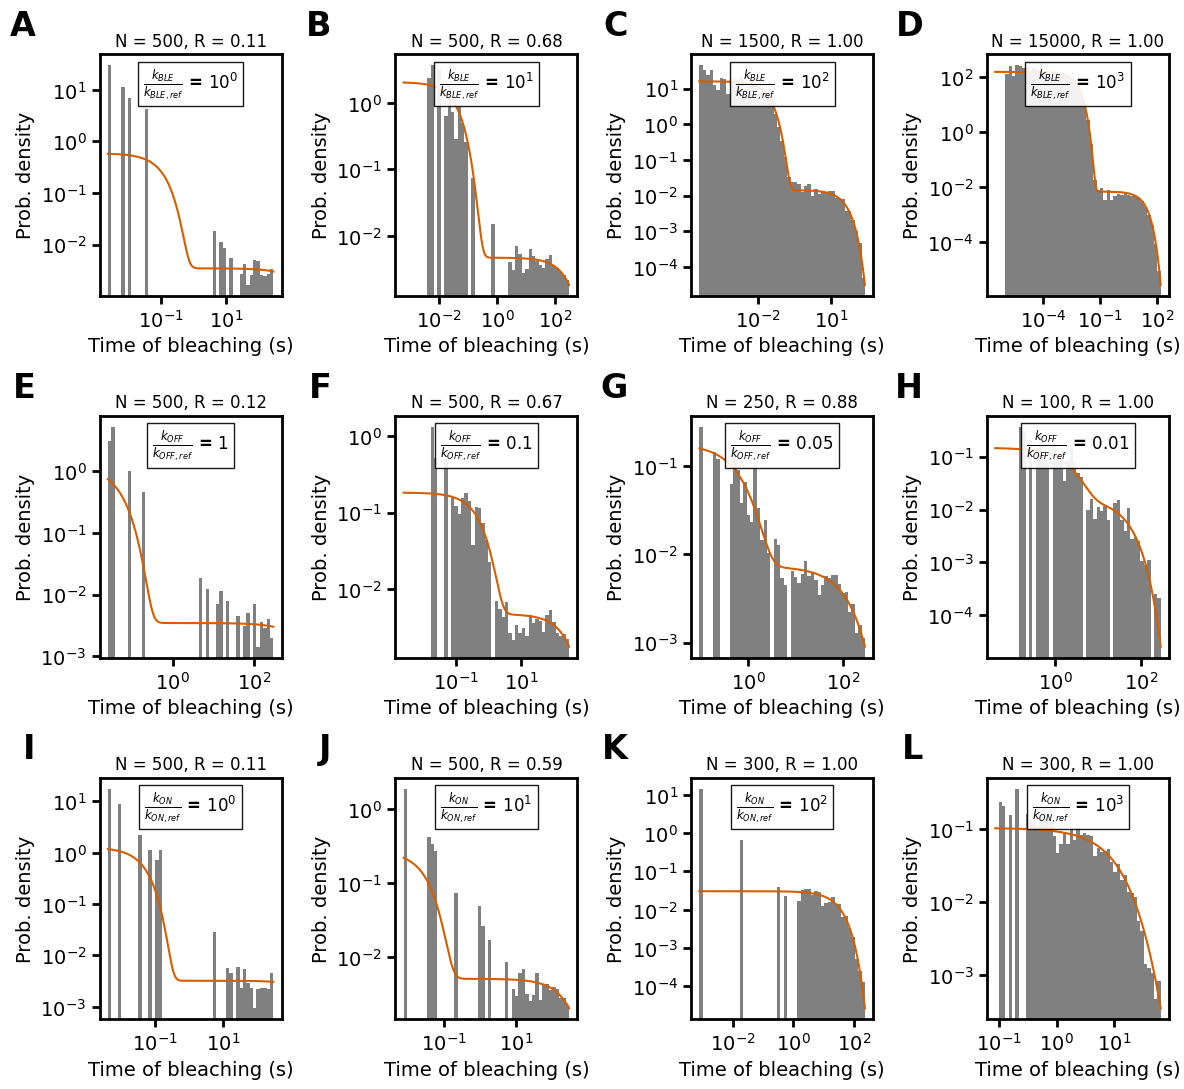

In [18]:
red = "#D55E00"
color = "grey"
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(12, 11))
label1 = [
    r"$\frac{k_{BLE}}{k_{BLE,ref}}$",
    r"$\frac{k_{OFF}}{k_{OFF,ref}}$",
    r"$\frac{k_{ON}}{k_{ON,ref}}$",
]
label2 = [
    [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"],
    [r"$1$", r"$0.1$", r"$0.05$", r"$0.01$"],
    [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"],
]

for i, (bleaching_times_all, parameters_all_fit_cdf) in enumerate(
    zip(
        [bleaching_times_all_A, bleaching_times_all_B, bleaching_times_all_C],
        [parameters_all_fit_cdf_A, parameters_all_fit_cdf_B, parameters_all_fit_cdf_C],
    )
):
    for j, (bl_times, parameters) in enumerate(
        zip(bleaching_times_all, parameters_all_fit_cdf)
    ):
        pi, lambda1, lambda2 = parameters
        data = bl_times[:, 0][~np.isnan(bl_times[:, 0])]
        ratio = data.size / bl_times.shape[0]
        bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
        x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 1000)
        ax = fig.add_subplot(gs[i, j])
        fi.universal_figure(
            type_="hist", data=data, axes=ax, density=True, color=color, bins=bins
        )
        fi.universal_figure(
            type_="line",
            data=[x, dist.two_expon_mixture_pdf(x, lambda1, lambda2, pi)],
            axes=ax,
            yscale="log",
            xscale="log",
            xlabel="Time of bleaching (s)",
            ylabel="Prob. density",
            color=red,
            fontsize=14,
        )
        props = dict(boxstyle="square", facecolor="white", alpha=0.9, edgecolor="black")
        ax.text(
            0.5,
            0.95,
            f"{label1[i]} = {label2[i][j]}",
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top",
            ha="center",
            bbox=props,
        )
        ax.set_title(f'N = {bl_times.size}, R = {ratio:.2f}')

axes = fig.get_axes()
letters = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"]
for i, axis in enumerate(axes):
    offset = -0.35
    axis.text(
        offset,
        1.05,
        letters[i],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()

fig.savefig(
    saving_to + r"\single_f_PFA_gl_bl_times.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1,
)